In [2]:
import numpy as np
from skimage import io
import matplotlib
import matplotlib.pyplot as plt
import os
from glob import glob
import torch
import torch.nn as nn
from tqdm import tqdm
from PIL import Image

from torch.utils.data import DataLoader, Dataset
from torch.autograd import Variable
if not os.path.exists('./outputs'):
    os.mkdir('./outputs')

In [3]:
DATASET_PATH = r"E:\7711810\EuroSAT_RGB_split"

BATCH_SIZE = 64 # Number of images that are used for calculating gradients at each step

NUM_EPOCHS = 25 # Number of times we will go through all the training images. Do not go over 25

LEARNING_RATE = 0.001 # Controls the step size
MOMENTUM = 0.9 # Momentum for the gradient descent
WEIGHT_DECAY = 0.0005

In [4]:
from torchvision import datasets, models, transforms
data_transforms = transforms.Compose([
        transforms.Resize(64),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

train_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'train'), data_transforms)
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)


test_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'test'), data_transforms)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes

print('Dataloaders OK')
test_loader

Dataloaders OK


In [5]:
import os
from collections import Counter

# Number of images in training and testing datasets
print(f"Total training images: {len(train_dataset)}")
print(f"Total testing images: {len(test_dataset)}\n")

# Class names and label mapping
print("Class names and indices:")
for class_name, class_idx in train_dataset.class_to_idx.items():
    print(f"  {class_name}: {class_idx}")

# Class distribution in training set
train_classes = [sample[1] for sample in train_dataset.samples]
train_class_distribution = Counter(train_classes)
print("\nTraining class distribution:")
for idx, count in train_class_distribution.items():
    print(f"  {class_names[idx]}: {count} images")

# Class distribution in testing set
test_classes = [sample[1] for sample in test_dataset.samples]
test_class_distribution = Counter(test_classes)
print("\nTesting class distribution:")
for idx, count in test_class_distribution.items():
    print(f"  {class_names[idx]}: {count} images")

# Example image size and shape (after transform)
sample_img, sample_label = train_dataset[0]
print(f"\nSample image shape after transform: {sample_img.shape}")  # (C, H, W)


Total training images: 21600
Total testing images: 5400

Class names and indices:
  AnnualCrop: 0
  Forest: 1
  HerbaceousVegetation: 2
  Highway: 3
  Industrial: 4
  Pasture: 5
  PermanentCrop: 6
  Residential: 7
  River: 8
  SeaLake: 9

Training class distribution:
  AnnualCrop: 2400 images
  Forest: 2400 images
  HerbaceousVegetation: 2400 images
  Highway: 2000 images
  Industrial: 2000 images
  Pasture: 1600 images
  PermanentCrop: 2000 images
  Residential: 2400 images
  River: 2000 images
  SeaLake: 2400 images

Testing class distribution:
  AnnualCrop: 600 images
  Forest: 600 images
  HerbaceousVegetation: 600 images
  Highway: 500 images
  Industrial: 500 images
  Pasture: 400 images
  PermanentCrop: 500 images
  Residential: 600 images
  River: 500 images
  SeaLake: 600 images

Sample image shape after transform: torch.Size([3, 64, 64])


In [6]:
# Residual Network Architecture

In [7]:
#Create the model class with ResNet
def conv3x3(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = conv3x3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(out_channels, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        
    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 16 
        self.conv = conv3x3(3, 16)
        self.bn = nn.BatchNorm2d(16) 
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self.make_layer(block, 16, layers[0], 1)
        self.layer2 = self.make_layer(block, 32, layers[1], 2)
        self.layer3 = self.make_layer(block, 64, layers[2], 2)
        self.avg_pool = nn.AvgPool2d(16)
        self.fc = nn.Linear(64, num_classes)
        
    def make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if (stride != 1) or (self.in_channels != out_channels):
            downsample = nn.Sequential(conv3x3(self.in_channels, out_channels, stride=stride),
                                       nn.BatchNorm2d(out_channels))
        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for i in range(1, blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(x.size(0), -1)
        out = self.fc(out)
        return out

In [8]:
# Create models

In [13]:
# Create network
USE_CUDA = torch.cuda.is_available()
model = ResNet(ResidualBlock, [2, 2, 2])
if USE_CUDA:
    model = model.cuda()  
    
print('Network OK')
    

Network OK


In [14]:
# Define criterion, optimizer, and scheduler

criterion = nn.CrossEntropyLoss()  
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [15]:
# Main loop
train_loss = []
train_accuracy = []
test_loss = []
test_accuracy = []
epochs = []

for epoch in range(1, NUM_EPOCHS+1):
    print(f'\n\nRunning epoch {epoch} of {NUM_EPOCHS}...\n')
    epochs.append(epoch)

    #-------------------------Train-------------------------
    
    #Reset these below variables to 0 at the begining of every epoch
    correct = 0
    iterations = 0
    iter_loss = 0.0
    
    model.train()  # Put the network into training mode
    
    for i, (inputs, labels) in enumerate(train_loader):
        if USE_CUDA:
            inputs = inputs.cuda()
            labels = labels.cuda()        
            
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        iter_loss += loss.item()  # Accumulate the loss
        optimizer.zero_grad() # Clear off the gradient in (w = w - gradient)
        loss.backward()   # Backpropagation 
        optimizer.step()  # Update the weights
        
        # Record the correct predictions for training data 
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum()
        iterations += 1
        
    scheduler.step()
        
    # Record the training loss
    train_loss.append(iter_loss/iterations)
    # Record the training accuracy
    train_accuracy.append((100 * correct / len(train_dataset)))   
     
    #-------------------------Test--------------------------
    
    correct = 0
    iterations = 0
    testing_loss = 0.0
    
    model.eval()  # Put the network into evaluation mode
    
    for i, (inputs, labels) in enumerate(test_loader):

        if USE_CUDA:
            inputs = inputs.cuda()
            labels = labels.cuda()
        
        outputs = model(inputs)     
        loss = criterion(outputs, labels) # Calculate the loss
        testing_loss += loss.item()
        # Record the correct predictions for training data
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum()
        
        iterations += 1

    # Record the Testing loss
    test_loss.append(testing_loss/iterations)
    # Record the Testing accuracy
    test_accuracy.append((100 * correct / len(test_dataset)))
   
    print(f'\nEpoch {epoch} validation results: Loss={test_loss[-1]} | Accuracy={test_accuracy[-1]}\n')



Running epoch 1 of 25...



C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Epoch 1 validation results: Loss=1.0576308481833514 | Accuracy=63.685184478759766



Running epoch 2 of 25...


Epoch 2 validation results: Loss=0.5794430619653533 | Accuracy=80.24073791503906



Running epoch 3 of 25...


Epoch 3 validation results: Loss=0.47641519636792296 | Accuracy=84.01851654052734



Running epoch 4 of 25...


Epoch 4 validation results: Loss=3.0914968053207676 | Accuracy=66.96295928955078



Running epoch 5 of 25...


Epoch 5 validation results: Loss=0.5091334558585111 | Accuracy=82.59259033203125



Running epoch 6 of 25...


Epoch 6 validation results: Loss=0.49964459106764375 | Accuracy=83.03704071044922



Running epoch 7 of 25...


Epoch 7 validation results: Loss=0.392677561883979 | Accuracy=86.51851654052734



Running epoch 8 of 25...


Epoch 8 validation results: Loss=0.24238190665183698 | Accuracy=92.16666412353516



Running epoch 9 of 25...


Epoch 9 validation results: Loss=0.23738653373027988 | Accuracy=92.35185241699219



Running epoch 10 of 25.

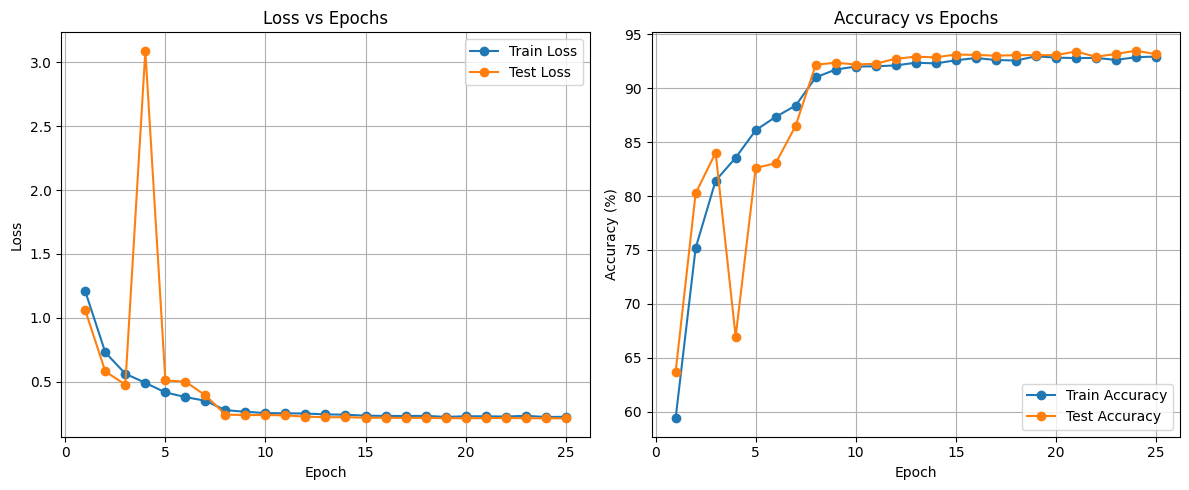

In [17]:
import matplotlib.pyplot as plt

# Plotting Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', marker='o')
plt.plot(epochs, test_loss, label='Test Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)

# Plotting Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracy, label='Test Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [18]:
print(f'Final train loss: {train_loss[-1]}')
print(f'Final test loss: {test_loss[-1]}')
print(f'Final train accuracy: {train_accuracy[-1]}')
print(f'Final test accuracy: {test_accuracy[-1]}')

Final train loss: 0.2244848191914474
Final test loss: 0.21252974365454386
Final train accuracy: 92.91666412353516
Final test accuracy: 93.14814758300781


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


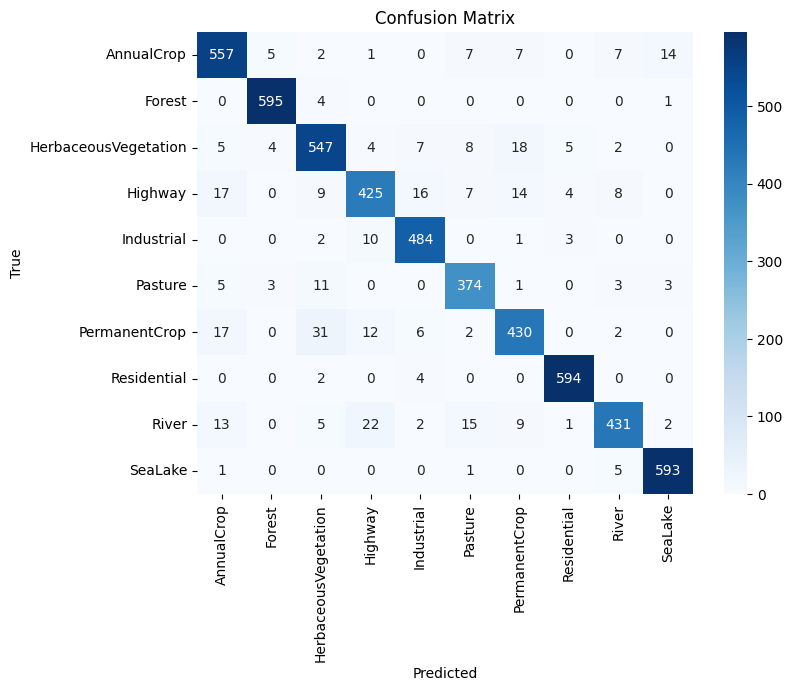

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
# Step 1: Evaluate the model on the test data and collect predictions
def get_all_preds(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

# Step 2: Generate confusion matrix
predictions, true_labels = get_all_preds(model, test_loader, device='cuda' if torch.cuda.is_available() else 'cpu')
cm = confusion_matrix(true_labels, predictions)

# Step 3: Plot it
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [20]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader, class_names, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute metrics
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')  # or 'macro'
    cm = confusion_matrix(true_labels, predictions)
    print(f"✅ Accuracy: {acc:.4f}")
    print(f"✅ F1 Score (weighted): {f1:.4f}")

In [21]:
 class_names = sorted(os.listdir('E:/7711810/EuroSAT_MS_split/test'))  # or your label list
evaluate_model(model, test_loader, class_names)


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


✅ Accuracy: 0.9315
✅ F1 Score (weighted): 0.9310


In [22]:
import torch

# Save only the model weights
torch.save(model.state_dict(), r"C:\Users\HP\SKYSERVE\ResNet_classification_Model.pth")
print("Model saved to disk")


Model saved to disk


In [23]:
# Create a dictionary to save all the necessary states
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss,
}

# Save the checkpoint dictionary to a .pth or .pt file
torch.save(checkpoint, r"C:\Users\HP\SKYSERVE\ResNet_checkpoint.pth")
print(f"Checkpoint saved at epoch {epoch}")

Checkpoint saved at epoch 25
